# 08 — Held-out Perplexity

Quantitative complement to the classifier attribution in `06_evaluation.ipynb`.
For each adapter we measure perplexity on every artist's **held-out** lyrics
(`data/eval.csv`), conditioned on the fixed training prompt (which is masked, so
only the lyric continuation is scored).

The result is a cross-artist matrix. If an adapter genuinely specialized, its
column-minimum lands on the diagonal — i.e. each artist's lyrics are best
predicted (lowest perplexity) by that artist's own adapter, and every adapter
beats the base model on its target artist.

Core logic lives in `perplexity.py` (CPU-tested); this notebook just runs the
forward passes, which need the GPU.

In [1]:
import pandas as pd

from generation.model import load_base_model
from evaluation.perplexity import perplexity_matrix, plot_perplexity_matrix

base_model, tokenizer = load_base_model()

eval_df = pd.read_csv("./data/eval.csv")
eval_df["artist"].value_counts()

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

/home/aliozkaya/uni/467/term_project/src/.venv/lib/python3.14/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


artist
Mastodon    15
Opeth       12
Death       12
Gojira       9
Tool         7
Name: count, dtype: int64

In [2]:
from config import adapter_registry

# Rows: base + one headline adapter (LoRA r8) per artist, plus the SW variant.
# Only adapters that exist on disk are included (skip not-yet-trained ones).
specs = adapter_registry()
adapter_map = {"base": None}
for a in specs:
    if a.path.exists():
        adapter_map[a.name] = str(a.path)

ppl = perplexity_matrix(base_model, tokenizer, adapter_map, eval_df)
ppl.round(1)

base: Death=30.4  Gojira=45.9  Mastodon=32.3  Opeth=57.7  Tool=18.6
gojira_lora_r8: Death=15.3  Gojira=18.2  Mastodon=18.7  Opeth=34.0  Tool=10.9
gojira_dora_r8: Death=15.2  Gojira=18.3  Mastodon=18.6  Opeth=33.9  Tool=10.9
tool_lora_r8: Death=16.1  Gojira=28.2  Mastodon=19.1  Opeth=37.0  Tool=4.3
tool_dora_r8: Death=16.3  Gojira=29.4  Mastodon=19.5  Opeth=38.4  Tool=4.2
death_lora_r8: Death=4.5  Gojira=70.3  Mastodon=49.5  Opeth=105.6  Tool=24.6
death_dora_r8: Death=4.4  Gojira=71.4  Mastodon=50.2  Opeth=109.2  Tool=26.4
mastodon_lora_r8: Death=23.0  Gojira=40.4  Mastodon=8.1  Opeth=54.4  Tool=14.6
mastodon_dora_r8: Death=22.6  Gojira=40.2  Mastodon=8.4  Opeth=54.6  Tool=14.8
opeth_lora_r8: Death=16.5  Gojira=29.0  Mastodon=20.7  Opeth=9.5  Tool=12.2
opeth_dora_r8: Death=17.0  Gojira=29.6  Mastodon=21.3  Opeth=9.7  Tool=12.6
gojira_lora_r4: Death=14.0  Gojira=17.8  Mastodon=16.8  Opeth=30.4  Tool=10.3
gojira_lora_r16: Death=17.6  Gojira=19.6  Mastodon=21.9  Opeth=40.8  Tool=12.2
tool_

,Death,Gojira,Mastodon,Opeth,Tool
base,30.4,45.9,32.3,57.7,18.6
gojira_lora_r8,15.3,18.2,18.7,34.0,10.9
gojira_dora_r8,15.2,18.3,18.6,33.9,10.9
tool_lora_r8,16.1,28.2,19.1,37.0,4.3
tool_dora_r8,16.3,29.4,19.5,38.4,4.2
death_lora_r8,4.5,70.3,49.5,105.6,24.6
death_dora_r8,4.4,71.4,50.2,109.2,26.4
mastodon_lora_r8,23.0,40.4,8.1,54.4,14.6
mastodon_dora_r8,22.6,40.2,8.4,54.6,14.8
opeth_lora_r8,16.5,29.0,20.7,9.5,12.2


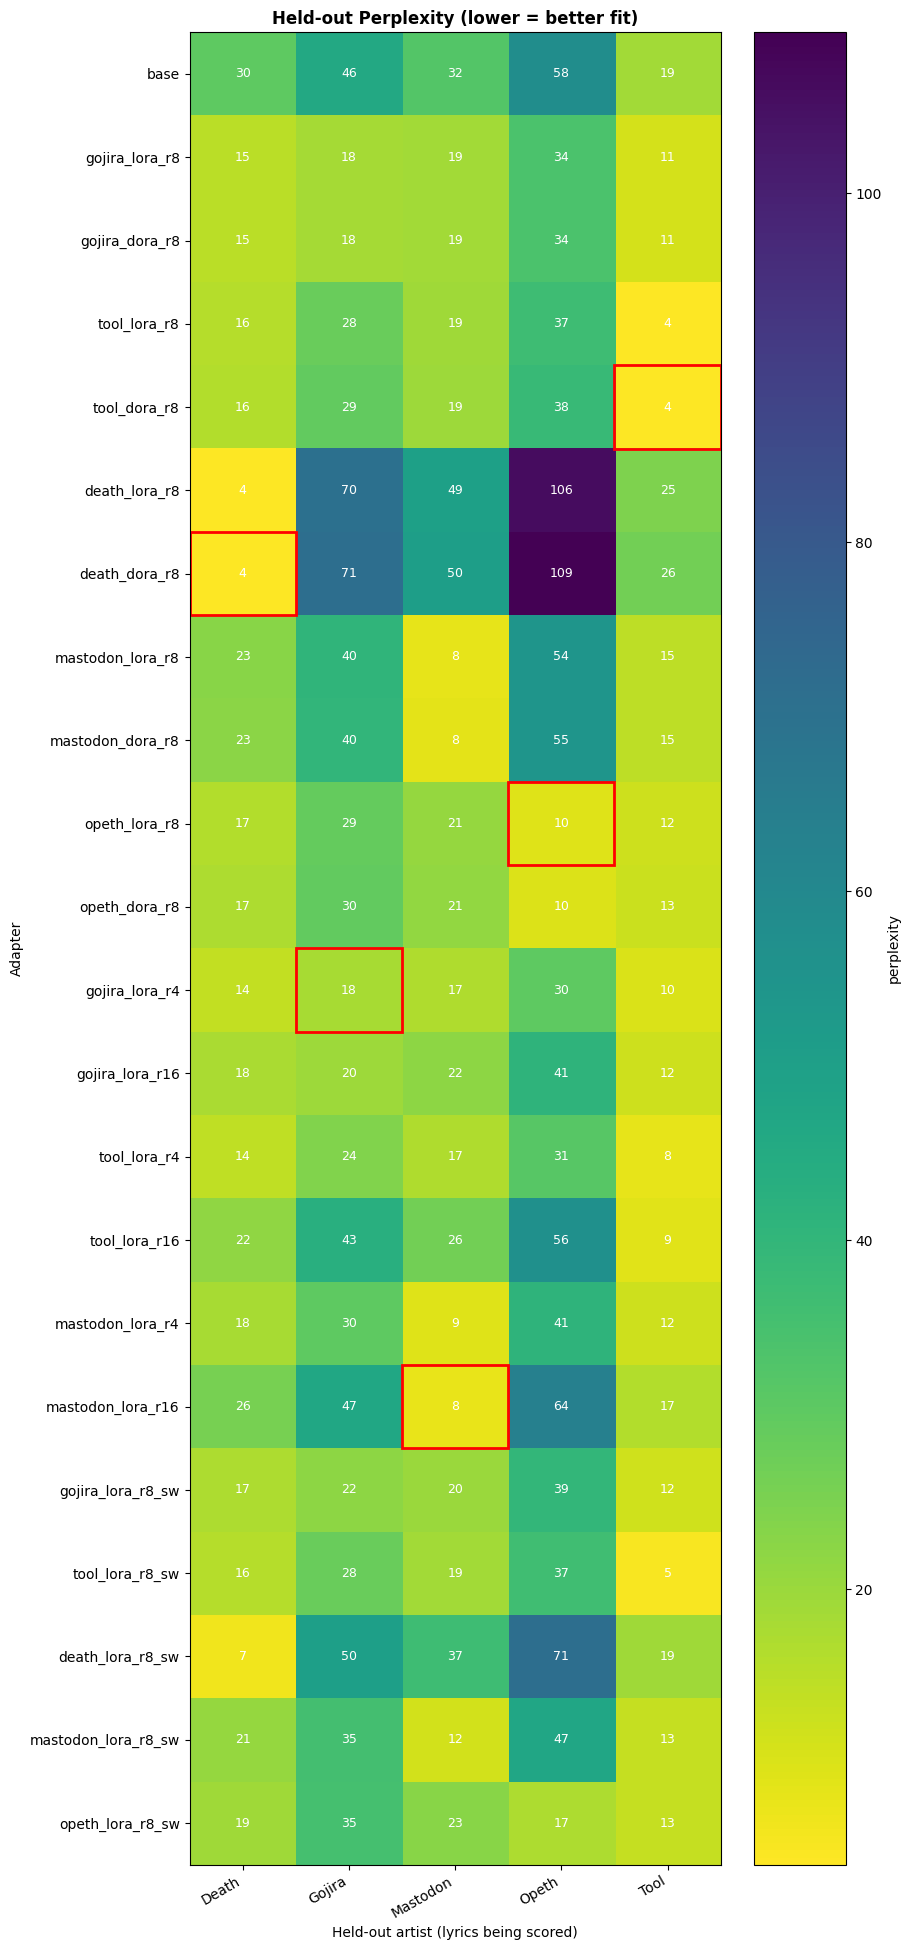

In [3]:
plot_perplexity_matrix(ppl)

## Reading the matrix

- **Lower = better fit.** Red boxes mark the per-column minimum.
- **Specialization:** each adapter's perplexity on its own artist should be the
  lowest in that column, and below the `base` row.
- **Cross-talk:** Gojira and Tool sit close in style, so off-diagonal cells will
  not be huge — the relevant signal is the *ordering* (own-artist lowest), not
  the absolute gap.
- Pairs with the attribution numbers in `06_evaluation.ipynb`: attribution says
  "the output reads like artist X"; perplexity says "the adapter assigns higher
  likelihood to artist X's real lyrics". Two independent angles on the same claim.